In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
plt.rcParams['text.usetex'] = False
plt.style.use('seaborn-v0_8-colorblind')
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

In [11]:
results = pd.read_csv("wandb_scMNC_final_expt_results.csv")
jointprior_df = results[results["model.name"] == "jointprior"].copy()

In [84]:
df = results[results['State'] == 'finished']
df = df[
    ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] +
      [col for col in df.columns if "val/loss/rec_loss" in col] +
       [col for col in df.columns if "val/conditional_generation" in col]
] 
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0.0)
# update names
old_name = df['model.name'] + df['model.aggregation']
new_name = old_name.str.replace("jointavg", "AVG", regex=False)
new_name = new_name.str.replace("jointprior", "JP", regex=False)
new_name = new_name.str.replace("joint", "", regex=False)
new_name = new_name.str.replace("avg", "", regex=False)
new_name = new_name.str.replace("moe", "MoE", regex=False)
new_name = new_name.str.replace("mopoe", "MoPoE", regex=False)
new_name = new_name.str.replace("mixedprior", "MMVM", regex=False)
new_name = new_name.str.replace("unimodal", "independent", regex=False)
df.loc[:, 'model.name'] = new_name
df["dataset.modalities_order"] = [int(res[0]) if len(res) == 1 else 
                                           int(res[1]) for res in df["dataset.modalities_order"].fillna('0')]

views = ["exp", "feat"]
relationships = []
indiv_results = []
one_to_one = []
column_names = []
for view_a in views:
  view_a_list = []
  one_to_one.append(view_a + "_to_" + view_a)
  for view_b in views:
    relationships.append(view_a + "_to_" + view_b)
    if view_a != view_b:
      view_a_list.append(view_b + "_to_" + view_a)
  indiv_results.append(view_a_list) # store view_a list
  column_names.append(str(view_a))
  indiv_results.append([view + "_cov" for view in view_a_list])
  column_names.append(str(view_a) + "_cov")
    
indiv_results.append(one_to_one)
column_names.append("one_to_one")
indiv_results.append([rel + "_cov" for rel in one_to_one])
column_names.append("one_to_one_cov")

relationships_full = ["final_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))
df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
metric_cols = [c for c in df.columns if "final_scores/coherence/" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]

In [61]:
columns_to_modify = ["final_scores/coherence/exp_to_exp", "final_scores/coherence/exp_to_feat", "final_scores/coherence/feat_to_exp", "final_scores/coherence/feat_to_feat"]
for column in columns_to_modify:
  column_cov = column + "_cov"
  df.loc[df["model.name"] != "MoE", column] = df.loc[df["model.name"] != "MoE", column_cov]

In [87]:
df_sub = df[(df["model.name"] != "JP") | (df["model.alpha_scalar"] == 0.8)]
df_sub.drop(columns=['model.aggregation', 'model.alpha_scalar',
       'dataset.modalities_order'], inplace=True)
mean_by_alpha = df_sub.groupby("model.name").mean().sort_index()
std_by_alpha = df_sub.groupby("model.name").std().reindex(mean_by_alpha.index).fillna(0.0)
# combine results into a single dataframe
mean_std_df = pd.concat([mean_by_alpha, std_by_alpha], axis=1, keys=['mean', 'std'])

/var/folders/_v/pwynlh7x69l93fbzfdrmlnxh0000gn/T/ipykernel_26491/75991176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub.drop(columns=['model.aggregation', 'model.alpha_scalar',


In [88]:
mean_by_alpha

,final_scores/coherence/exp_to_exp,final_scores/coherence/exp_to_exp_cov,final_scores/coherence/exp_to_feat,final_scores/coherence/exp_to_feat_cov,final_scores/coherence/feat_to_exp,final_scores/coherence/feat_to_exp_cov,final_scores/coherence/feat_to_feat,final_scores/coherence/feat_to_feat_cov,final_scores/cond_rec_loss,final_scores/cond_rec_loss_cov,final_scores/downstream_lr/aggregated/exp,final_scores/downstream_lr/aggregated/feat,final_scores/downstream_lr/unimodal/exp,final_scores/downstream_lr/unimodal/feat,final_scores/rec_loss,val/loss/rec_loss_exp,val/loss/rec_loss_feat,cov_better
model.name,,,,,,,,,,,,,,,,,,
JP,0.896591,0.896591,0.772443,0.772443,0.874432,0.874432,0.682670,0.682670,2286.144873,2286.613428,0.962500,0.912500,0.962500,0.912500,2285.812598,-1372.888086,-27.345664,0.55
MMVM,0.892330,0.892045,0.229545,0.787500,0.267330,0.865625,0.686648,0.686648,2289.670508,2289.626807,0.961080,0.913352,0.961080,0.913352,2289.829443,-1371.891846,-27.495823,0.55
MoE,0.889489,0.889489,0.766761,0.763352,0.898580,0.885227,0.691193,0.690341,2377.218359,2377.239453,0.934943,0.934943,0.953693,0.917898,2727.633447,-1486.517676,-37.176274,0.15


In [89]:
columns_to_keep = ['final_scores/coherence/exp_to_exp', 'final_scores/coherence/feat_to_exp', 'final_scores/coherence/feat_to_feat', 'final_scores/coherence/exp_to_feat', 'final_scores/downstream_lr/unimodal/exp',
       'final_scores/downstream_lr/unimodal/feat',
  'val/loss/rec_loss_exp', 'val/loss/rec_loss_feat']
mean_by_alpha = mean_by_alpha[columns_to_keep]
std_by_alpha = std_by_alpha[columns_to_keep]

In [91]:
mean_by_alpha.columns = ['T to T', 'E to T', 'E to E', 'T to E', 'LR T',
       'LR E',
  'Rec Loss / T', 'Rec Loss / E']

In [75]:
# round to 3sf and make a latex table of the mean_by_alpha table 
mean_by_alpha.round(3).to_latex()
with open("mean_by_alpha.tex", "w") as f:
    f.write(mean_by_alpha.round(3).to_latex())


In [ ]:
std_by_alpha = std_by_alpha[columns_to_keep]
std_by_alpha.columns = ['T to T', 'E to T', 'E to E', 'T to E', 'LR T',
       'LR E',
  'Rec Loss / T', 'Rec Loss / E']
std_by_alpha.round(3).to_latex()
with open("std_by_alpha.tex", "w") as f:
    f.write(std_by_alpha.round(3).to_latex())

Results for standard imputation appraoch within JPVAE

In [93]:
columns_to_modify = ["final_scores/coherence/exp_to_exp", "final_scores/coherence/exp_to_feat", "final_scores/coherence/feat_to_exp", "final_scores/coherence/feat_to_feat"]
for column in columns_to_modify:
  column_cov = column + "_cov"
  df.loc[df["model.name"] == "JP", column] = df.loc[df["model.name"] == "JP", column_cov]
df_sub = df[(df["model.name"] != "JP") | (df["model.alpha_scalar"] == 0.8)]
df_sub.drop(columns=['model.aggregation', 'model.alpha_scalar',
       'dataset.modalities_order'], inplace=True)
mean_by_alpha = df_sub.groupby("model.name").mean().sort_index()
std_by_alpha = df_sub.groupby("model.name").std().reindex(mean_by_alpha.index).fillna(0.0)
# combine results into a single dataframe
mean_std_df = pd.concat([mean_by_alpha, std_by_alpha], axis=1, keys=['mean', 'std'])
columns_to_keep =['final_scores/coherence/exp_to_exp', 'final_scores/coherence/feat_to_exp', 'final_scores/coherence/feat_to_feat', 'final_scores/coherence/exp_to_feat', 'final_scores/downstream_lr/unimodal/exp',
       'final_scores/downstream_lr/unimodal/feat',
  'val/loss/rec_loss_exp', 'val/loss/rec_loss_feat']
mean_by_alpha = mean_by_alpha[columns_to_keep]
std_by_alpha = std_by_alpha[columns_to_keep]
mean_by_alpha.columns = ['T to T', 'E to T', 'E to E', 'T to E', 'LR T',
       'LR E',
  'Rec Loss / T', 'Rec Loss / E']
std_by_alpha.columns = ['T to T', 'E to T', 'E to E', 'T to E', 'LR T',
       'LR E',
  'Rec Loss / T', 'Rec Loss / E']
mean_by_alpha.round(3).to_latex()
with open("mean_by_alpha_standard_imputation.tex", "w") as f:
    f.write(mean_by_alpha.round(3).to_latex())
std_by_alpha.round(3).to_latex()
with open("std_by_alpha_standard_imputation.tex", "w") as f:
    f.write(std_by_alpha.round(3).to_latex())

/var/folders/_v/pwynlh7x69l93fbzfdrmlnxh0000gn/T/ipykernel_26491/3640918437.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub.drop(columns=['model.aggregation', 'model.alpha_scalar',


In [94]:
mean_by_alpha

,T to T,E to T,E to E,T to E,LR T,LR E,Rec Loss / T,Rec Loss / E
model.name,,,,,,,,
JP,0.896591,0.874432,0.682670,0.772443,0.962500,0.912500,-1372.888086,-27.345664
MMVM,0.892330,0.267330,0.686648,0.229545,0.961080,0.913352,-1371.891846,-27.495823
MoE,0.889489,0.898580,0.691193,0.766761,0.953693,0.917898,-1486.517676,-37.176274


# $\alpha$ plot

## Covariance based imputation

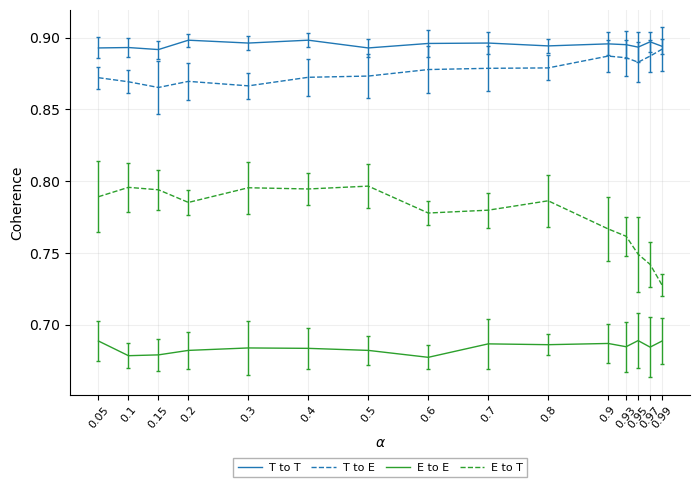

In [98]:
# Plot average best_scores/coherence/*_cov for jointprior with std error bars as a function of model.alpha_scalar

coherence_cov_cols = ["best_scores/coherence/exp_to_exp_cov","best_scores/coherence/feat_to_exp_cov","best_scores/coherence/feat_to_feat_cov","best_scores/coherence/exp_to_feat_cov"]


plot_df = jointprior_df[["model.alpha_scalar"] + coherence_cov_cols].dropna(
    subset=["model.alpha_scalar"]
)

mean_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].mean().sort_index()
std_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].std().reindex(mean_by_alpha.index).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 5))
legend_handles = []
legend_labels = []

for col in coherence_cov_cols:
    metric_name = col.replace("best_scores/coherence/", "")
    metric_name = metric_name.replace("exp", "T")
    metric_name = metric_name.replace("feat", "E")
    label_parts = metric_name.replace("_cov", "").split("_to_")
    legend_name = f"{label_parts[1]} to {label_parts[0]}"
    line_style = "--" if metric_name in {"T_to_E_cov", "E_to_T_cov"} else "-"
    line_color = "tab:blue" if metric_name in {"T_to_T_cov", "E_to_T_cov"} else "tab:green"

    ax.errorbar(
        mean_by_alpha.index,
        mean_by_alpha[col],
        yerr=std_by_alpha[col],
        marker="",
        capsize=1.5,
        linewidth=1,
        label="_nolegend_",
        linestyle=line_style,
        color=line_color
    )

    legend_handles.append(
        Line2D([0], [0], color=line_color, linestyle=line_style, linewidth=1)
    )
    legend_labels.append(legend_name)

alpha_vals = mean_by_alpha.index.to_numpy()
ax.set_xticks(alpha_vals, labels=[f"{a:g}" for a in alpha_vals], rotation=50, fontsize=8)
# ax.set_yticks([i/100 for i in range(0, 101, 20)])
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Coherence")
# ax.set_title("jointprior coherence vs alpha (mean ± std)")
ax.grid(alpha=0.2)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=8,
    handlelength=2.2,
    columnspacing=1.0,
    handletextpad=0.6,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="0.7",
)
# plt.tight_layout()
plt.savefig("../results_figures/scMNC_coherence_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()


## Different imputation approaches

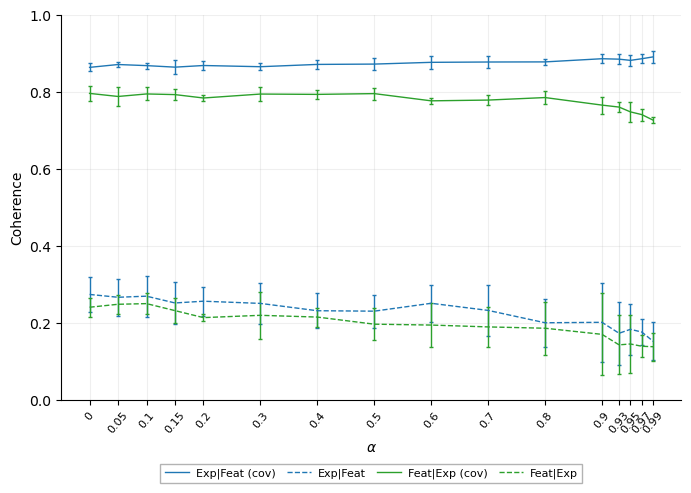

In [143]:
# Plot average best_scores/coherence/*_cov for jointprior with std error bars as a function of model.alpha_scalar

coherence_cov_cols = ["best_scores/coherence/feat_to_exp_cov","best_scores/coherence/feat_to_exp","best_scores/coherence/exp_to_feat_cov","best_scores/coherence/exp_to_feat"]

plot_df = jointprior_df[["model.alpha_scalar"] + coherence_cov_cols].dropna(
    subset=["model.alpha_scalar"]
)

mean_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].mean().sort_index()
std_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].std().reindex(mean_by_alpha.index).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 5))
legend_handles = []
legend_labels = []

for col in coherence_cov_cols:
    metric_name = col.replace("best_scores/coherence/", "")
    metric_name = metric_name.replace("exp", "Exp")
    metric_name = metric_name.replace("feat", "Feat")
    label_parts = metric_name.replace("_cov", "").split("_to_")
    legend_name = f"{label_parts[1]}|{label_parts[0]}"
    if "_cov" in metric_name:
        legend_name += " (cov)"
    line_style = "--" if metric_name in {"Exp_to_Feat", "Feat_to_Exp"} else "-"
    line_color = "tab:blue" if metric_name in {"Feat_to_Exp_cov", "Feat_to_Exp"} else "tab:green"

    ax.errorbar(
        mean_by_alpha.index,
        mean_by_alpha[col],
        yerr=std_by_alpha[col],
        marker="",
        capsize=1.5,
        linewidth=1,
        label="_nolegend_",
        linestyle=line_style,
        color=line_color
    )

    legend_handles.append(
        Line2D([0], [0], color=line_color, linestyle=line_style, linewidth=1)
    )
    legend_labels.append(legend_name)

alpha_vals = mean_by_alpha.index.to_numpy()
ax.set_xticks(alpha_vals, labels=[f"{a:g}" for a in alpha_vals], rotation=50, fontsize=8)
ax.set_yticks([i/100 for i in range(0, 101, 20)])
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Coherence")
ax.grid(alpha=0.2)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=8,
    handlelength=2.2,
    columnspacing=1.0,
    handletextpad=0.6,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="0.7",
)
plt.savefig("../results_figures/scMNC_coherence_vs_alpha_cov_vs_no_cov.png", dpi=300, bbox_inches="tight")
plt.show()

## Reconstruction loss

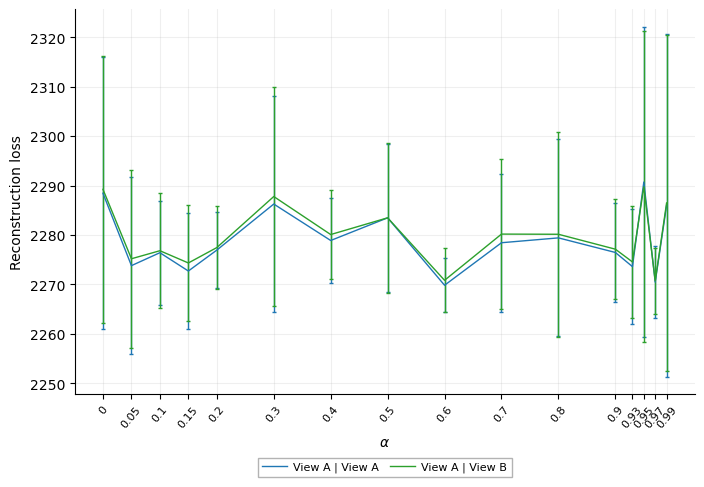

In [131]:
coherence_cov_cols = ["best_scores/rec_loss", "best_scores/cond_rec_loss"]
plot_df = jointprior_df[["model.alpha_scalar"] + coherence_cov_cols].dropna(
    subset=["model.alpha_scalar"]
)

mean_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].mean().sort_index()
std_by_alpha = plot_df.groupby("model.alpha_scalar")[coherence_cov_cols].std().reindex(mean_by_alpha.index).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 5))
legend_handles = []
legend_labels = []

for col in coherence_cov_cols:
    metric_name = col.replace("best_scores/", "")
    legend_name = "View A | View A" if metric_name == "rec_loss" else "View A | View B"

    line_color = "tab:blue" if legend_name == "View A | View A" else "tab:green"

    ax.errorbar(
        mean_by_alpha.index,
        mean_by_alpha[col],
        yerr=std_by_alpha[col],
        marker="",
        capsize=1.5,
        linewidth=1,
        label="_nolegend_",
        color=line_color
    )

    legend_handles.append(
        Line2D([0], [0], linewidth=1, color=line_color)
    )
    legend_labels.append(legend_name)

alpha_vals = mean_by_alpha.index.to_numpy()
ax.set_xticks(alpha_vals, labels=[f"{a:g}" for a in alpha_vals], rotation=50, fontsize=8)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Reconstruction loss")
ax.grid(alpha=0.2)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=8,
    handlelength=2.2,
    columnspacing=1.0,
    handletextpad=0.6,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="0.7",
  
)
plt.savefig("../results_figures/scMNC_recon_loss_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()


## Latent representation

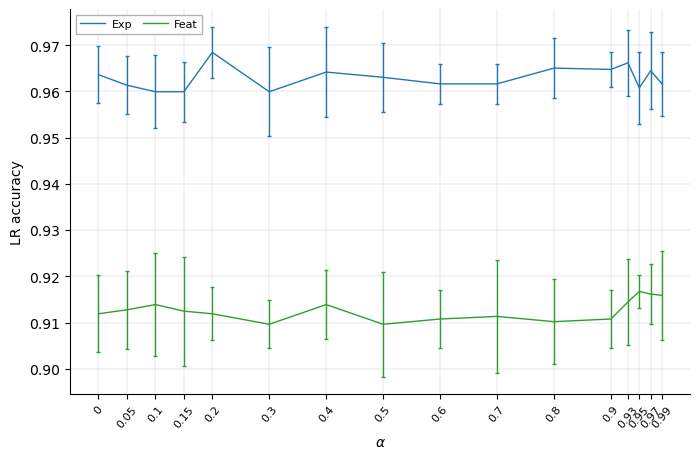

In [4]:
downstream_lr_cols = [
    "best_scores/downstream_lr/unimodal/exp",
    "best_scores/downstream_lr/unimodal/feat",
]
plot_df = jointprior_df[["model.alpha_scalar"] + downstream_lr_cols].dropna(subset=["model.alpha_scalar"])

mean_by_alpha = plot_df.groupby("model.alpha_scalar")[downstream_lr_cols].mean().sort_index()
std_by_alpha = plot_df.groupby("model.alpha_scalar")[downstream_lr_cols].std().reindex(mean_by_alpha.index).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 5))
legend_handles = []
legend_labels = []

for col in downstream_lr_cols:
    view = col.split("/")[-1]
    legend_name = "Exp" if view == "exp" else "Feat"
    line_style = "-"
    line_color = "tab:blue" if view == "exp" else "tab:green"

    ax.errorbar(
        mean_by_alpha.index,
        mean_by_alpha[col],
        yerr=std_by_alpha[col],
        marker="",
        capsize=1.5,
        linewidth=1,
        linestyle=line_style,
        color=line_color,
        label="_nolegend_",
    )

    legend_handles.append(
        Line2D([0], [0], color=line_color, linestyle=line_style, linewidth=1)
    )
    legend_labels.append(legend_name)

alpha_vals = mean_by_alpha.index.to_numpy()
ax.set_xticks(alpha_vals, labels=[f"{a:g}" for a in alpha_vals], rotation=50, fontsize=8)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("LR accuracy")
ax.grid(linewidth=0.2)
ax.legend(
    legend_handles,
    legend_labels,
    loc="best",
    ncol=2,
    fontsize=8,
    handlelength=2.2,
    columnspacing=1.0,
    handletextpad=0.6,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="0.7",
)
plt.savefig("../results_figures/scMNC_LR_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

## Differences table

In [5]:
cond_rec_loss_diff = abs(results['best_scores/cond_rec_loss'] - results["best_scores/cond_rec_loss_cov"]).mean()
exp_to_exp_diff = abs(results['best_scores/coherence/exp_to_exp'] - results["best_scores/coherence/exp_to_exp_cov"]).mean()
feat_to_feat_diff = abs(results['best_scores/coherence/feat_to_feat'] - results["best_scores/coherence/feat_to_feat_cov"]).mean()
lr_exp_diff = abs(results['best_scores/downstream_lr/unimodal/exp'] - results['best_scores/downstream_lr/aggregated/exp']).mean()
lr_feat_diff = abs(results['best_scores/downstream_lr/unimodal/feat'] - results['best_scores/downstream_lr/aggregated/feat']).mean()

print("Mean absolute differences when using different imputation approaches between:")
print(f"Conditional reconstruction loss: {cond_rec_loss_diff:.4f}")
print(f"View to view coherence (Exp): {exp_to_exp_diff:.4f}")
print(f"View to view coherence (Feat): {feat_to_feat_diff:.4f}")
print("Mean absolute differences when using different latent variables:")
print(f"Exp: {lr_exp_diff:.4f}")
print(f"Feat: {lr_feat_diff:.4f}")

# save as a table
diff_df = pd.DataFrame({
    "Metric": [
        "Conditional reconstruction loss",
        "View to view coherence (Exp)",
        "View to view coherence (Feat)",
        "Downstream LR accuracy (Exp)",
        "Downstream LR accuracy (Feat)"
    ],
    "Mean Absolute Difference": [
        cond_rec_loss_diff,
        exp_to_exp_diff,
        feat_to_feat_diff,
        lr_exp_diff,
        lr_feat_diff
    ]
})
diff_df.to_csv("../results_figures/scMNC_differences.csv", index=False)

Mean absolute differences when using different imputation approaches between:
Conditional reconstruction loss: 0.2768
View to view coherence (Exp): 0.0000
View to view coherence (Feat): 0.0010
Mean absolute differences when using different latent variables:
Exp: 0.0011
Feat: 0.0014


# Model comparison

# remaining


In [ ]:
df = results[
    ["model.name", "model.aggregation", "model.alpha_scalar"] + [col for col in results.columns if "best_scores" in col] 
] 
df.head()




Update names.

In [81]:
old_name = df['model.name'] + df['model.aggregation']
new_name = old_name.str.replace("jointavg", "AVG", regex=False)
new_name = new_name.str.replace("jointprior", "JP", regex=False)
new_name = new_name.str.replace("joint", "", regex=False)
new_name = new_name.str.replace("avg", "", regex=False)
new_name = new_name.str.replace("moe", "MoE", regex=False)
new_name = new_name.str.replace("mopoe", "MoPoE", regex=False)
new_name = new_name.str.replace("mixedprior", "MMVM", regex=False)
new_name = new_name.str.replace("unimodal", "independent", regex=False)
df.loc[:, 'model.name'] = new_name
df.head()

,model.name,model.aggregation,model.alpha_scalar,best_scores/coherence/exp_to_exp,best_scores/coherence/exp_to_exp_cov,best_scores/coherence/exp_to_feat,best_scores/coherence/exp_to_feat_cov,best_scores/coherence/feat_to_exp,best_scores/coherence/feat_to_exp_cov,best_scores/coherence/feat_to_feat,best_scores/coherence/feat_to_feat_cov,best_scores/cond_rec_loss,best_scores/cond_rec_loss_cov,best_scores/downstream_lr/aggregated/exp,best_scores/downstream_lr/aggregated/feat,best_scores/downstream_lr/unimodal/exp,best_scores/downstream_lr/unimodal/feat,best_scores/rec_loss,best_scores/val_loss
0,JP,avg,0.0,0.893466,0.893466,0.232955,0.767045,0.258523,0.875000,0.673295,0.673295,2291.739990,2291.458740,0.961648,0.910511,0.961648,0.910511,2290.179688,2440.809814
1,JP,avg,0.0,0.889205,0.889205,0.259943,0.795455,0.265625,0.849432,0.676136,0.677557,2269.304199,2269.171143,0.963068,0.904830,0.963068,0.904830,2269.275391,2422.939453
2,JP,avg,0.0,0.897727,0.897727,0.274148,0.818182,0.342330,0.866477,0.686080,0.686080,2312.660889,2312.647461,0.964489,0.904830,0.964489,0.904830,2312.827637,2464.398682
3,JP,avg,0.0,0.890625,0.890625,0.218750,0.808239,0.221591,0.859375,0.678977,0.678977,2317.412354,2317.175537,0.973011,0.914773,0.973011,0.914773,2316.855957,2469.793457
4,JP,avg,0.0,0.899148,0.899148,0.223011,0.796875,0.286932,0.873580,0.696023,0.697443,2255.134277,2255.113037,0.955966,0.924716,0.955966,0.924716,2253.149170,2405.885742


In [77]:
(df['best_scores/coherence/exp_to_exp'] - df['best_scores/coherence/exp_to_exp_cov']).sum()
(df['best_scores/coherence/feat_to_feat'] - df['best_scores/coherence/feat_to_feat_cov']).sum()

np.float64(0.008523106575012207)

In [82]:
agg_df = df.groupby(["model.name",'model.aggregation', "model.alpha_scalar"]).mean().reset_index()
agg_df.head()

,model.name,model.aggregation,model.alpha_scalar,best_scores/coherence/exp_to_exp,best_scores/coherence/exp_to_exp_cov,best_scores/coherence/exp_to_feat,best_scores/coherence/exp_to_feat_cov,best_scores/coherence/feat_to_exp,best_scores/coherence/feat_to_exp_cov,best_scores/coherence/feat_to_feat,best_scores/coherence/feat_to_feat_cov,best_scores/cond_rec_loss,best_scores/cond_rec_loss_cov,best_scores/downstream_lr/aggregated/exp,best_scores/downstream_lr/aggregated/feat,best_scores/downstream_lr/unimodal/exp,best_scores/downstream_lr/unimodal/feat,best_scores/rec_loss,best_scores/val_loss
0,JP,avg,0.00,0.894034,0.894034,0.241761,0.797159,0.275000,0.864773,0.682102,0.682670,2289.250342,2289.113184,0.963636,0.911932,0.963636,0.911932,2288.457568,2440.765430
1,JP,avg,0.05,0.892898,0.892898,0.249432,0.789205,0.267614,0.872159,0.688068,0.688636,2275.202246,2275.272998,0.961364,0.912784,0.961364,0.912784,2273.808105,2425.552490
2,JP,avg,0.10,0.893182,0.893182,0.251136,0.795739,0.270455,0.869318,0.678693,0.678409,2276.826367,2276.859326,0.959943,0.913920,0.959943,0.913920,2276.423535,2427.973730
3,JP,avg,0.15,0.891761,0.891761,0.232955,0.794034,0.252841,0.865341,0.680114,0.678977,2274.349121,2274.337744,0.959943,0.912500,0.959943,0.912500,2272.719678,2422.381494
4,JP,avg,0.20,0.898295,0.898295,0.214773,0.785227,0.257386,0.869602,0.682955,0.682102,2277.465625,2277.776807,0.968466,0.911932,0.968466,0.911932,2276.954688,2426.301855


In [83]:
max_df = df.groupby(["model.name",'model.aggregation', "model.alpha_scalar"]).max().reset_index()
max_df.head()

,model.name,model.aggregation,model.alpha_scalar,best_scores/coherence/exp_to_exp,best_scores/coherence/exp_to_exp_cov,best_scores/coherence/exp_to_feat,best_scores/coherence/exp_to_feat_cov,best_scores/coherence/feat_to_exp,best_scores/coherence/feat_to_exp_cov,best_scores/coherence/feat_to_feat,best_scores/coherence/feat_to_feat_cov,best_scores/cond_rec_loss,best_scores/cond_rec_loss_cov,best_scores/downstream_lr/aggregated/exp,best_scores/downstream_lr/aggregated/feat,best_scores/downstream_lr/unimodal/exp,best_scores/downstream_lr/unimodal/feat,best_scores/rec_loss,best_scores/val_loss
0,JP,avg,0.00,0.899148,0.899148,0.274148,0.818182,0.342330,0.875000,0.696023,0.697443,2317.412354,2317.175537,0.973011,0.924716,0.973011,0.924716,2316.855957,2469.793457
1,JP,avg,0.05,0.901989,0.901989,0.282670,0.828125,0.303977,0.883523,0.707386,0.707386,2291.969482,2291.912842,0.970170,0.921875,0.970170,0.921875,2289.710205,2440.868164
2,JP,avg,0.10,0.900568,0.900568,0.295455,0.815341,0.330966,0.880682,0.687500,0.688920,2288.449219,2288.154297,0.971591,0.924716,0.971591,0.924716,2287.614746,2438.275391
3,JP,avg,0.15,0.899148,0.899148,0.276989,0.813920,0.301136,0.886364,0.696023,0.696023,2293.860840,2293.737549,0.970170,0.928977,0.970170,0.928977,2292.345703,2441.506836
4,JP,avg,0.20,0.901989,0.901989,0.228693,0.796875,0.292614,0.884943,0.700284,0.700284,2292.555908,2292.600830,0.977273,0.916193,0.977273,0.916193,2290.518799,2438.678711


In [84]:
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = False
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-colorblind')
jointprior_df = results[results["model.name"] == "jointprior"].copy()

The performance of JPVAE in reconstructing a view, and the quality of their latent representation, remains constant across $\alpha$ values. The ability, The latent spaces become more correlated, with the conditional generation decreasing as $\alpha$ increases for the original imputation approach. 

The performance of the orginal and conditional approaches yields nearly exactly the same result for view-to-view reconstruction with the difference in results being 0.0 and over the total 80 hyperparameter tuning experiments  

Latent representation accuracy is unaffected by the $\alpha$ value ensuring that ... does not   

Generate new columns of averages.

Add a column indicating the rate at which the covariance based imputation approach gives better results than the standard approach. 

In [24]:
relationships_full = ["best_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))

df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
df.head()

/var/folders/_v/pwynlh7x69l93fbzfdrmlnxh0000gn/T/ipykernel_95615/339233633.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cov_better'] = np.mean(np.array(cov_better), axis = 0)


,model.name,model.aggregation,model.alpha_scalar,best_scores/coherence/exp_to_exp,best_scores/coherence/exp_to_exp_cov,best_scores/coherence/exp_to_feat,best_scores/coherence/exp_to_feat_cov,best_scores/coherence/feat_to_exp,best_scores/coherence/feat_to_exp_cov,best_scores/coherence/feat_to_feat,best_scores/coherence/feat_to_feat_cov,best_scores/cond_rec_loss,best_scores/cond_rec_loss_cov,best_scores/downstream_lr/aggregated/exp,best_scores/downstream_lr/aggregated/feat,best_scores/downstream_lr/unimodal/exp,best_scores/downstream_lr/unimodal/feat,best_scores/rec_loss,best_scores/val_loss,cov_better
0,JP,avg,0.0,0.893466,0.893466,0.232955,0.767045,0.258523,0.875000,0.673295,0.673295,2291.739990,2291.458740,0.961648,0.910511,0.961648,0.910511,2290.179688,2440.809814,0.50
1,JP,avg,0.0,0.889205,0.889205,0.259943,0.795455,0.265625,0.849432,0.676136,0.677557,2269.304199,2269.171143,0.963068,0.904830,0.963068,0.904830,2269.275391,2422.939453,0.75
2,JP,avg,0.0,0.897727,0.897727,0.274148,0.818182,0.342330,0.866477,0.686080,0.686080,2312.660889,2312.647461,0.964489,0.904830,0.964489,0.904830,2312.827637,2464.398682,0.50
3,JP,avg,0.0,0.890625,0.890625,0.218750,0.808239,0.221591,0.859375,0.678977,0.678977,2317.412354,2317.175537,0.973011,0.914773,0.973011,0.914773,2316.855957,2469.793457,0.50
4,JP,avg,0.0,0.899148,0.899148,0.223011,0.796875,0.286932,0.873580,0.696023,0.697443,2255.134277,2255.113037,0.955966,0.924716,0.955966,0.924716,2253.149170,2405.885742,0.75


Great a dataframe of the averages over results

In [33]:
metric_cols = [c for c in df.columns if "best_scores/coherence/" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]

In [34]:
metric_cols

['best_scores/coherence/exp_to_exp',
 'best_scores/coherence/exp_to_feat',
 'best_scores/coherence/feat_to_exp',
 'best_scores/coherence/feat_to_feat']

In [35]:
df_subset = df.fillna(-1)
# df_subset.loc[df_subset['model.name']== 'independent', 'model.alpha_scalar'] = 0
df_subset = df_subset[df_subset["model.alpha_scalar"] != -1]
df_subset['model.name'] = df_subset['model.name'] + ["-" + str(x) for x in df_subset['model.alpha_scalar']]
df_subset['model.name'] = [str(x) for x in df_subset['model.alpha_scalar']]
# df_subset = df_subset[df_subset["dataset.modalities_order"] == 0]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()
model_means_jp

,best_scores/coherence/exp_to_exp,best_scores/coherence/exp_to_feat,best_scores/coherence/feat_to_exp,best_scores/coherence/feat_to_feat
model.name,,,,
0.0,0.890246,0.395739,0.478030,0.688542
0.05,0.892898,0.249432,0.267614,0.688068
0.1,0.893182,0.251136,0.270455,0.678693
0.15,0.891761,0.232955,0.252841,0.680114
0.2,0.898295,0.214773,0.257386,0.682955
0.3,0.896307,0.220739,0.251705,0.683807
0.4,0.898295,0.216193,0.232670,0.683523
0.5,0.892898,0.197727,0.231534,0.682670
0.6,0.896023,0.195455,0.251989,0.678125


## $\alpha$ tuning

### Functions


In [36]:
model_means_jp_cov

,best_scores/coherence/exp_to_exp_cov,best_scores/coherence/exp_to_feat_cov,best_scores/coherence/feat_to_exp_cov,best_scores/coherence/feat_to_feat_cov
model.name,,,,
0.0,0.890246,0.769981,0.870739,0.688542
0.05,0.892898,0.789205,0.872159,0.688636
0.1,0.893182,0.795739,0.869318,0.678409
0.15,0.891761,0.794034,0.865341,0.678977
0.2,0.898295,0.785227,0.869602,0.682102
0.3,0.896307,0.795455,0.866477,0.683807
0.4,0.898295,0.794602,0.872443,0.683523
0.5,0.892898,0.796591,0.873295,0.682102
0.6,0.896023,0.777841,0.877841,0.677273


### Plots

## Heatmaps

In [198]:
# --- Compute averages over repeats for each model ---
df['model.name'] = pd.Categorical(df['model.name'], labels, ordered=True)
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  np.logical_and(df_subset["model.alpha_scalar"] == 0.97, 
                 df_subset["dataset.modalities_order"] == 1),
  df_subset["model.alpha_scalar"] == 0
  )]
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
AVG,0.550000,0.344050,0.353886,0.274519,0.341967,0.685577,0.771554,0.770713,0.520413,0.767989,...,0.655268,0.655429,0.683794,0.842668,0.756691,0.318690,0.351342,0.348157,0.258814,0.440865
MoE,0.780849,0.867728,0.874900,0.852204,0.828165,0.846254,0.899139,0.907171,0.886799,0.858173,...,0.815805,0.864083,0.874239,0.868009,0.814083,0.828566,0.880409,0.888622,0.866567,0.851062
MoPoE,0.700761,0.691086,0.709155,0.684335,0.629547,0.736679,0.860337,0.823077,0.790585,0.719231,...,0.684896,0.745032,0.763401,0.846655,0.650681,0.653966,0.704147,0.720713,0.691887,0.731931
MMVM,0.850200,0.846254,0.853466,0.839383,0.829447,0.809455,0.944311,0.898838,0.879407,0.869010,...,0.795312,0.877123,0.882492,0.944471,0.857432,0.773197,0.855509,0.858954,0.842468,0.885216
JP,0.879507,0.050731,0.117839,0.121444,0.122496,0.058644,0.974509,0.052083,0.025140,0.044271,...,0.117187,0.066106,0.099058,0.964643,0.120693,0.117087,0.065905,0.110827,0.122446,0.905098


In [199]:
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
model_means_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
AVG,0.536659,0.512179,0.504107,0.493870,0.427524,0.311558,0.767748,0.738582,0.784655,0.682011,...,0.289083,0.708133,0.695994,0.841166,0.635637,0.271514,0.629547,0.620553,0.635877,0.440645
MoE,0.780849,0.801382,0.808954,0.604107,0.767588,0.758474,0.899159,0.828005,0.609896,0.779367,...,0.729307,0.796454,0.800681,0.868129,0.749139,0.752985,0.810096,0.818770,0.610256,0.851122
MoPoE,0.700801,0.618049,0.646254,0.504808,0.571995,0.598217,0.860417,0.772095,0.595673,0.675601,...,0.580909,0.707332,0.728506,0.846655,0.637881,0.530629,0.638742,0.656971,0.514002,0.731931
MMVM,0.850160,0.786038,0.788622,0.696494,0.535998,0.362220,0.944231,0.831090,0.727684,0.556210,...,0.373458,0.822696,0.822456,0.944491,0.565365,0.360757,0.787780,0.789603,0.694111,0.885296
JP,0.879507,0.730569,0.722656,0.597806,0.534756,0.619291,0.974509,0.961088,0.877254,0.809896,...,0.417268,0.814653,0.817959,0.964643,0.614734,0.378255,0.753205,0.751903,0.626903,0.905048


In [200]:
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}

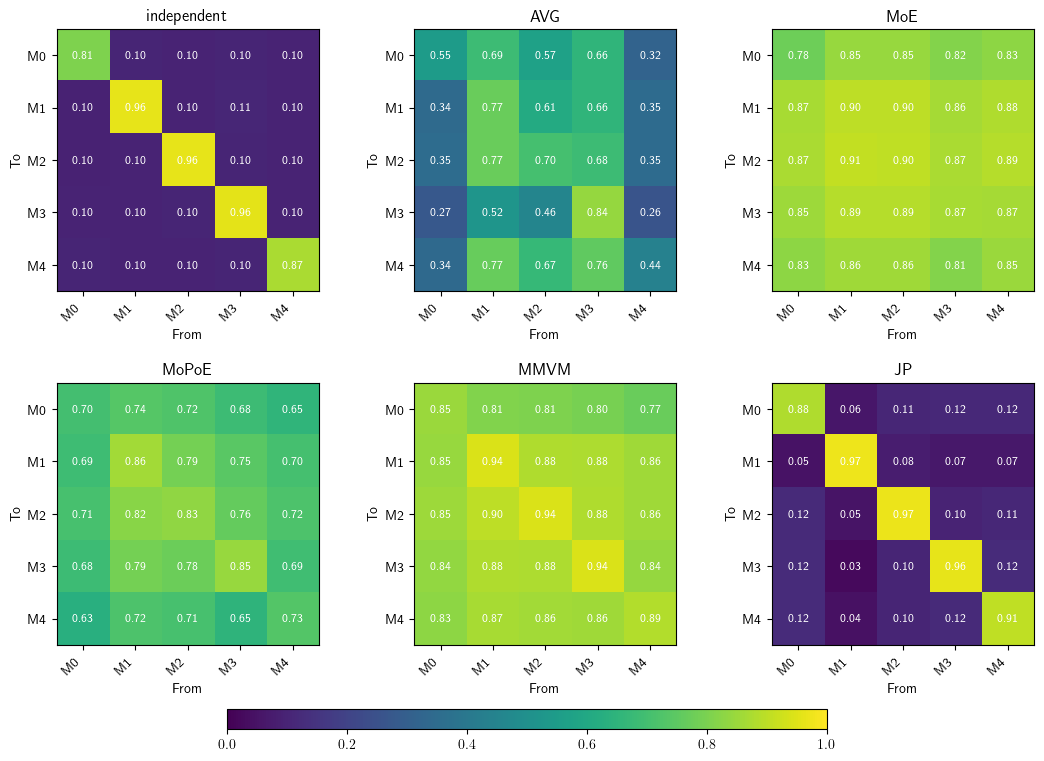

In [201]:
produce_plots(matrices,  "results_figures/methods_heatmaps.png")

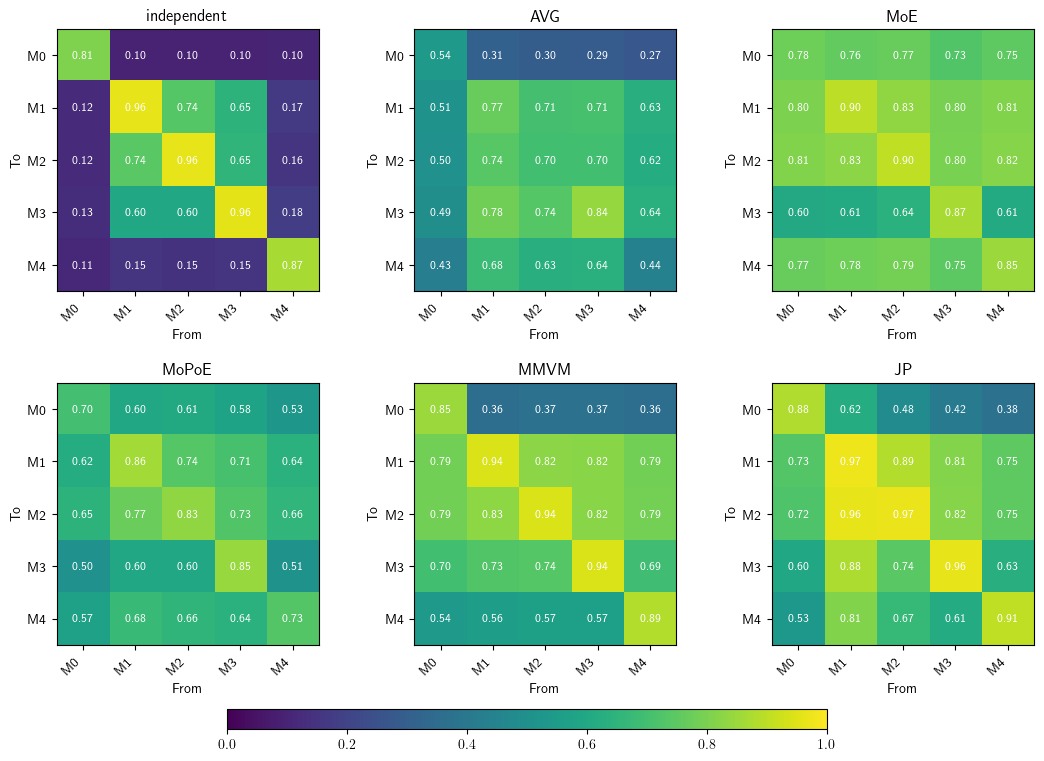

In [202]:
produce_plots(matrices_cov,  "results_figures/methods_heatmaps_cov.png")

In [203]:
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 

Investigating the impact of different values of $\alpha$ on the performance of JPVAE.

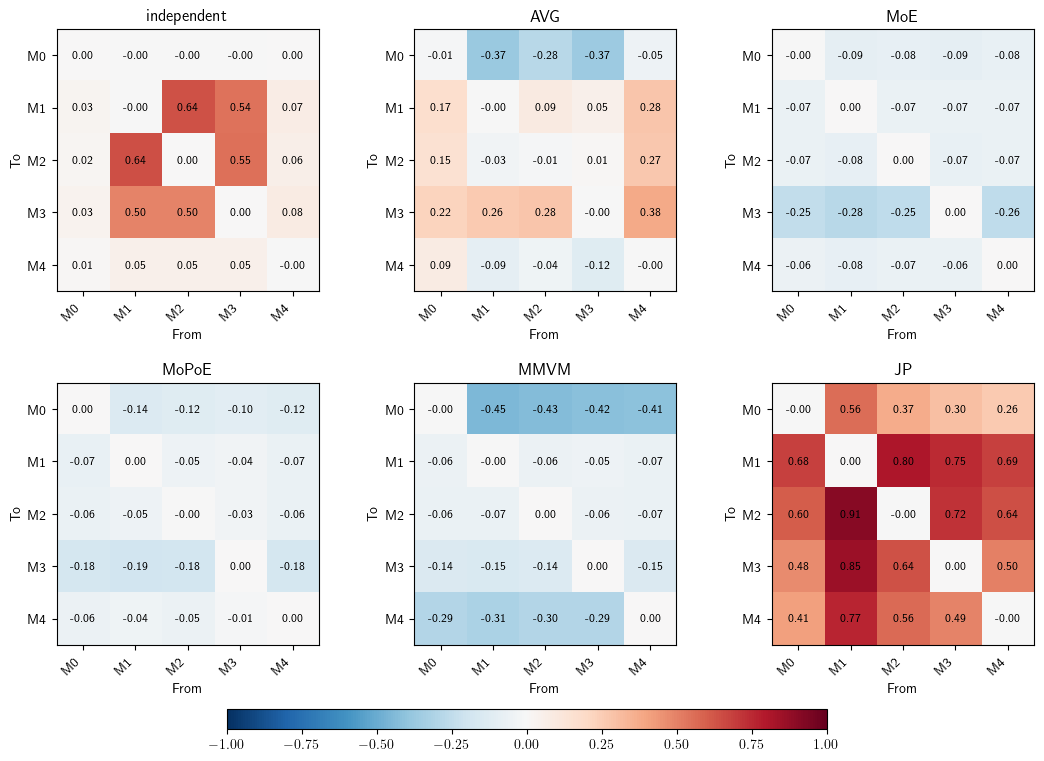

In [204]:
produce_plots(matrix_diff,  "results_figures/methods_heatmaps_diff.png",v_min =-1, color_map='RdBu_r', text_color='k')

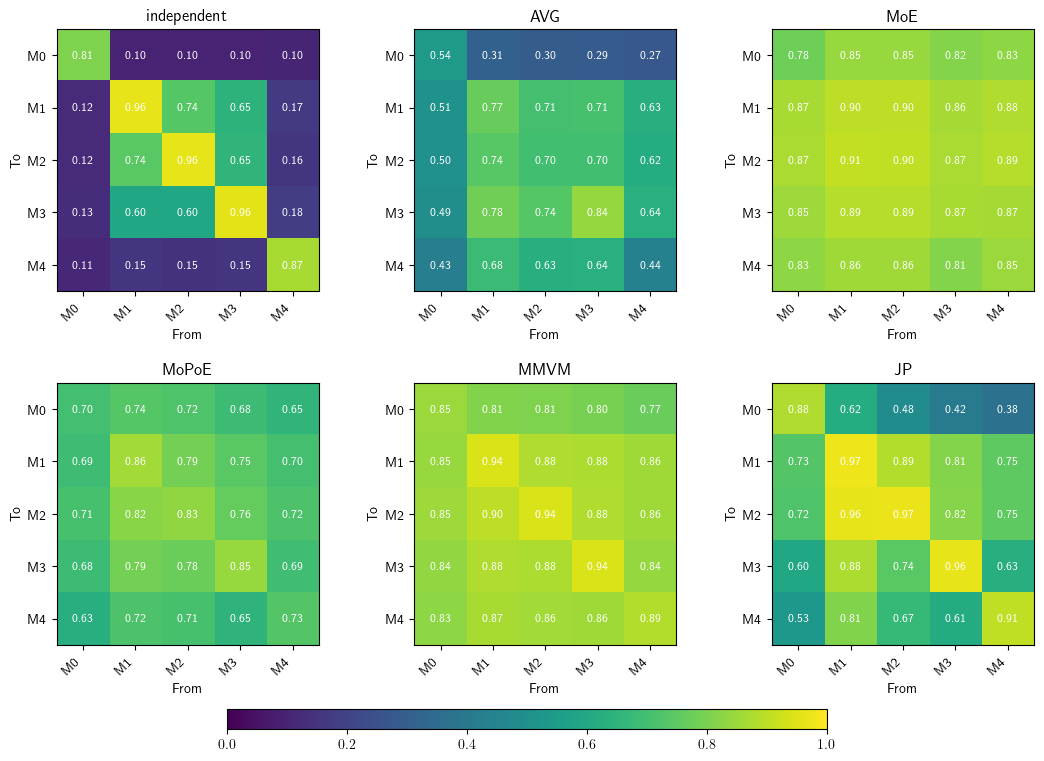

In [205]:
best_results = {
                'independent':matrices_cov['independent'], 
                'AVG':matrices_cov['AVG'],
                'MoE':matrices['MoE'],
                'MoPoE':matrices['MoPoE'],
                'MMVM':matrices['MMVM'],
                'JP':matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png")

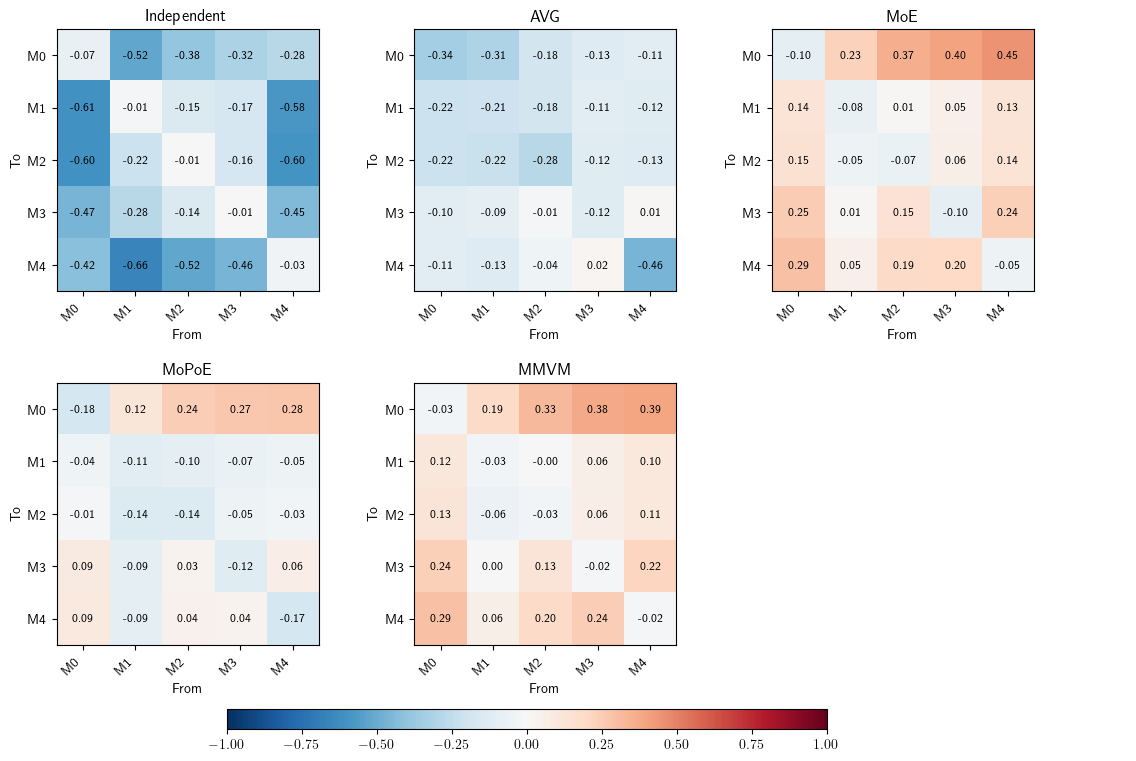

In [207]:
best_results = {'Independent':matrices_cov['independent']-matrices_cov['JP'],
                'AVG':matrices_cov['AVG']-matrices_cov['JP'],
                'MoE':matrices['MoE']-matrices_cov['JP'],
                'MoPoE':matrices['MoPoE']-matrices_cov['JP'],
                'MMVM':matrices['MMVM']-matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png", v_min=-1, color_map='RdBu_r', text_color='k', n_cols=3, n_rows=2)

In [208]:
model_map = {'AVG':1, "JP":1, "independent":1, "MMVM":0, "MoPoE":0, "MoE":0}
df_subset["covariance"] = df_subset["model.name"].map(model_map)


for view_a in views:
  var_name = view_a + "_to_" + view_a
  df_subset["coh/" + var_name] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name])
  for view_b in views:
    var_name2 = view_a + "_to_" + view_b
    df_subset["coh/" + var_name2] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name2 + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name2])
    
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,coh/m3_to_m3,coh/m3_to_m0,coh/m3_to_m1,coh/m3_to_m2,coh/m3_to_m4,coh/m4_to_m4,coh/m4_to_m0,coh/m4_to_m1,coh/m4_to_m2,coh/m4_to_m3
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.868389,0.821615,0.875701,0.881010,0.819511,0.857873,0.837841,0.889523,0.891627,0.879507
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.859776,0.810296,0.863682,0.868890,0.839643,0.858073,0.821715,0.876703,0.885216,0.855869
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.879207,0.815104,0.868289,0.871795,0.797476,0.841446,0.829928,0.882612,0.890525,0.864684
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.872796,0.820813,0.858073,0.882212,0.793670,0.858574,0.830829,0.886018,0.896434,0.880809
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.859876,0.811198,0.854667,0.867288,0.820112,0.839343,0.822516,0.867188,0.879307,0.851963


In [209]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  average_name = view + "_average"
  best_name = view + "_best"
  df_subset[average_name] = df_subset[cols].mean(axis=1)
  df_subset[best_name] = df_subset[cols].max(axis=1)

df_subset['average_overall'] = df_subset[[view + "_average" for view in views]].mean(axis=1)
df_subset['best_overall'] = df_subset[[view + "_best" for view in views]].mean(axis=1)
df_subset['average_coherence'] = df_subset[["coh/" + view + "_to_" + view for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1_best,m2_average,m2_best,m3_average,m3_best,m4_average,m4_best,average_overall,best_overall,average_coherence
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.906350,0.888572,0.904147,0.883238,0.899539,0.842223,0.858774,0.868429,0.884355,0.862460
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.898438,0.883388,0.914764,0.864583,0.892929,0.858749,0.887620,0.861924,0.889223,0.857051
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.893329,0.887495,0.898938,0.871094,0.880809,0.827799,0.843349,0.859585,0.872336,0.861138
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.897035,0.891401,0.909956,0.879207,0.894832,0.809846,0.826422,0.858398,0.874940,0.865365
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.904547,0.880308,0.908053,0.870267,0.894531,0.858148,0.885517,0.863467,0.890845,0.857232


In [210]:
df_subset[["model.name", "final_scores/coherence/m0_to_m4_cov"]]

,model.name,final_scores/coherence/m0_to_m4_cov
1,MoE,0.735677
6,MoE,0.750401
7,MoE,0.806991
13,MoE,0.759515
14,MoE,0.785357
26,MoPoE,0.606671
28,MoPoE,0.649239
31,MoPoE,0.467448
32,JP,0.505409
34,MoPoE,0.574419


In [211]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  cols.append("final_scores/coherence/" + view + "_to_" + view)
  average_name = view + "_average_inc_view"
  df_subset[average_name] = df_subset[cols].mean(axis=1)

df_subset['average_overall_inc_view'] = df_subset[[view + "_average_inc_view" for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m4_best,average_overall,best_overall,average_coherence,m0_average_inc_view,m1_average_inc_view,m2_average_inc_view,m3_average_inc_view,m4_average_inc_view,average_overall_inc_view
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.858774,0.868429,0.884355,0.862460,0.827905,0.890445,0.892208,0.880268,0.845353,0.867236
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.887620,0.861924,0.889223,0.857051,0.814924,0.880188,0.887400,0.863622,0.858614,0.860950
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.843349,0.859585,0.872336,0.861138,0.824820,0.883053,0.888361,0.872716,0.830529,0.859896
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.826422,0.858398,0.874940,0.865365,0.826502,0.880349,0.894591,0.877925,0.819591,0.859792
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.885517,0.863467,0.890845,0.857232,0.824700,0.877264,0.886558,0.868189,0.854387,0.862220


In [213]:
  # Keep only the relevant columns
cols_avg = [view + "_average" for view in views]
cols_avg.append('average_overall')
cols_avg_inc_views = [view + "_average_inc_view" for view in views]
cols_avg_inc_views.append('average_overall_inc_view')
cols_best = [view + "_best" for view in views]
cols_best.append('best_overall')
cols_view_to_view = ["coh/" + view + "_to_" + view for view in views]
cols_view_to_view.append("average_coherence")

In [214]:
columns = df_subset.columns

In [215]:
agg_cols = [col for col in columns if "final_scores/downstream_lr/aggregated" in col]
uni_cols = [col for col in columns if "final_scores/downstream_lr/unimodal" in col]

In [216]:
df_subset['unimodal_average'] = df_subset[uni_cols].mean(axis=1)
df_subset['agg_average'] = df_subset[agg_cols].mean(axis=1)
uni_cols.append('unimodal_average')
agg_cols.append("agg_average")

In [217]:
main_cols = [cols[-1] for cols in [cols_avg, cols_best, cols_view_to_view, uni_cols, agg_cols]]

In [219]:
def coherence_plots(df, cols_to_use, x_title, title, file_path, combination_plot = False):
  cols = cols_to_use.copy()
  cols.append("model.name")
  df_subset = df[cols]

  # Melt into long format for grouped plotting
  df_long = df_subset.melt(id_vars="model.name", 
                          var_name="metric", 
                          value_name="score")
  df_long["metric"] = df_long["metric"].str.replace("_average", "", regex=False)
  if combination_plot:
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "LR (unimodal)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "LR (aggregation)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_overall", "Coherence (average)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("best_overall", "Coherence (best)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Coherence (view to view)", regex=False)
  else:
    df_long["metric"] = df_long["metric"].str.replace("coh/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_best", "", regex=False)
    
    df_long["metric"] = df_long["metric"].str.replace("best_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("final_scores/downstream_lr/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("aggregated/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_inc_view", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("m", "M", regex=False)  
  
  # Compute mean and SEM by model + metric
  summary = (
      df_long.groupby(["model.name", "metric"], observed=True)
      .agg(mean=("score", "mean"), sem=("score", "sem"))
      .reset_index()
  )
  # Pivot so we can plot grouped bars
  metrics = summary["metric"].unique()
  models = summary["model.name"].unique()
  x = summary["model.name"].unique()
  x = np.arange(len(metrics))
  # bar_width = 0.25
  bar_width = 0.8 / len(metrics)
  if combination_plot:
    bar_width = 0.8 / (len(metrics) + 1)

  fig, ax = plt.subplots(figsize=(10,6))

  # Plot each metric as a group
  for i, model in enumerate(models):
      data = summary[summary["model.name"] == model]
      ax.bar(
          x + i * bar_width,
          data.set_index("metric").loc[metrics, "mean"],
          yerr=data.set_index("metric").loc[metrics, "sem"],
          # color=colors[i],
          width=bar_width,
          label=model,
          capsize=4
      )

  # Formatting
  ax.set_xlim(-0.25)
  ax.set_xticks(x + bar_width * (len(models)-1)/2)
  ax.set_xticklabels(metrics)
  ax.set_ylabel("Mean Score (± SE)")
  ax.set_xlabel(x_title)
  ax.set_title(title)
  ax.legend(title="Model", loc = "lower right")

  plt.tight_layout()
  plt.savefig(file_path)

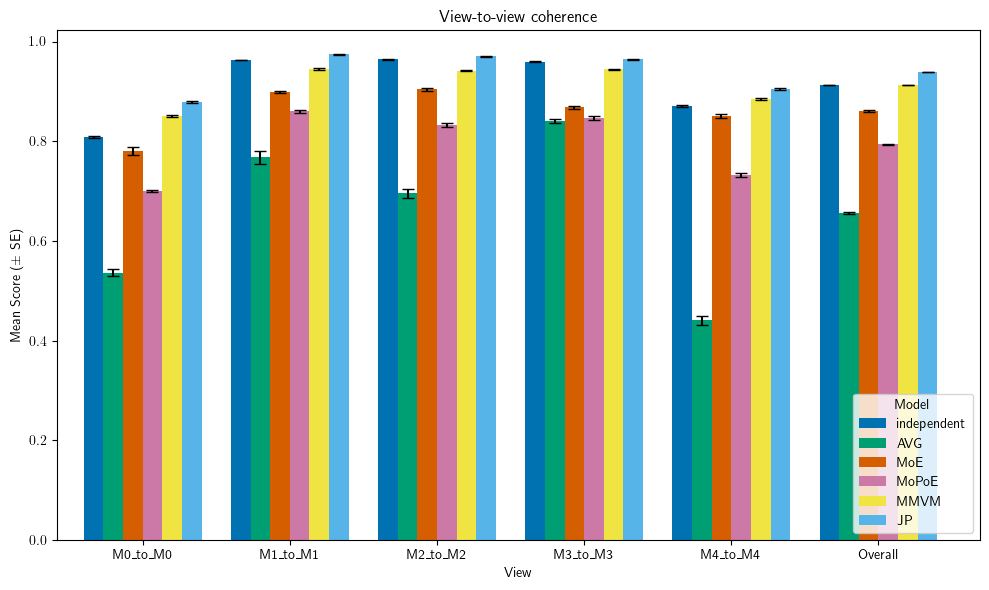

In [220]:
coherence_plots(df_subset, cols_view_to_view, "View", "View-to-view coherence", "results_figures/view_to_view_coherence_barplot.png")

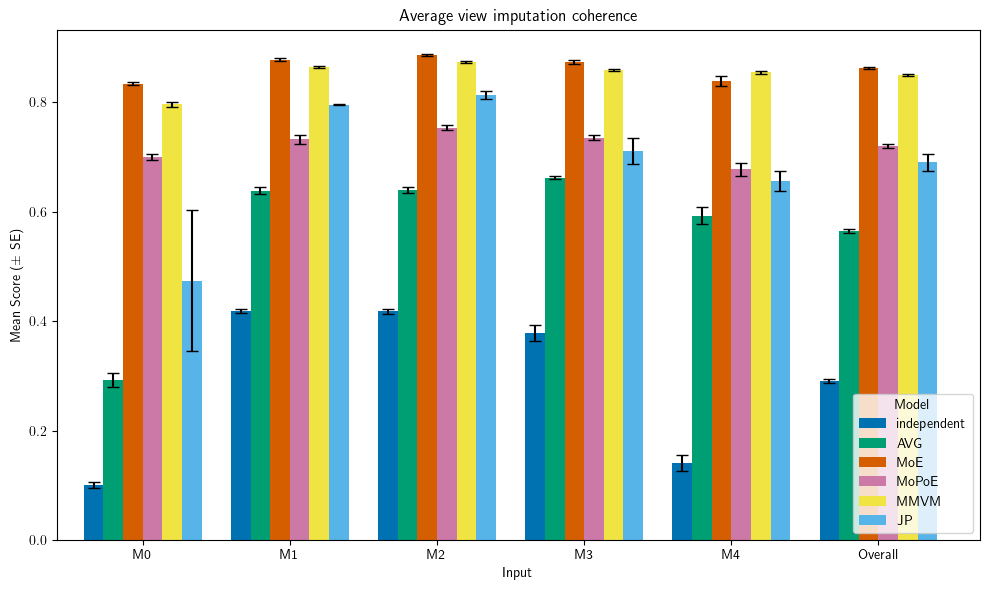

In [221]:
coherence_plots(df_subset, cols_avg, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_barplot.png")

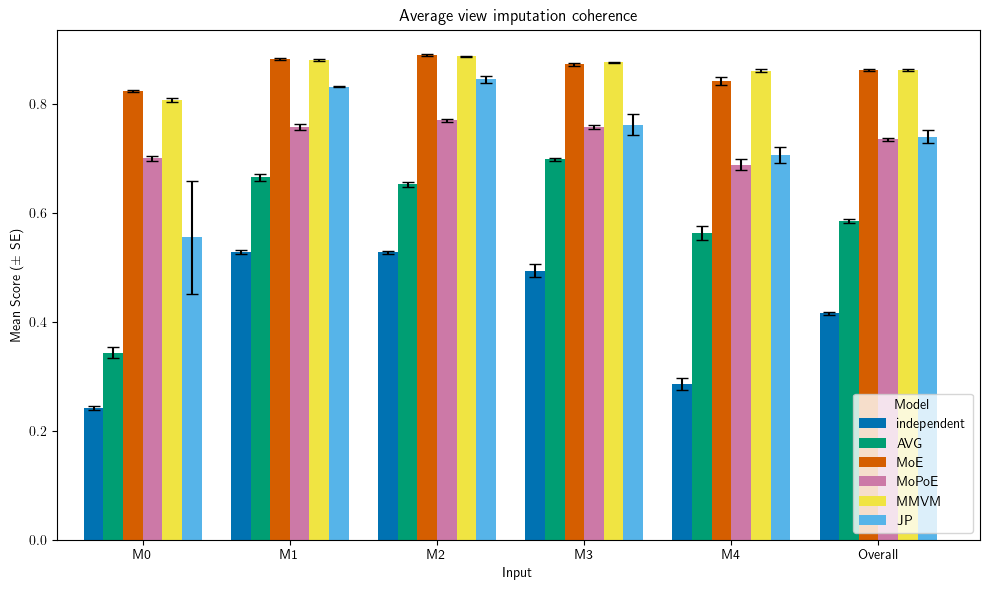

In [223]:
coherence_plots(df_subset, cols_avg_inc_views, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_inc_views_barplot.png")

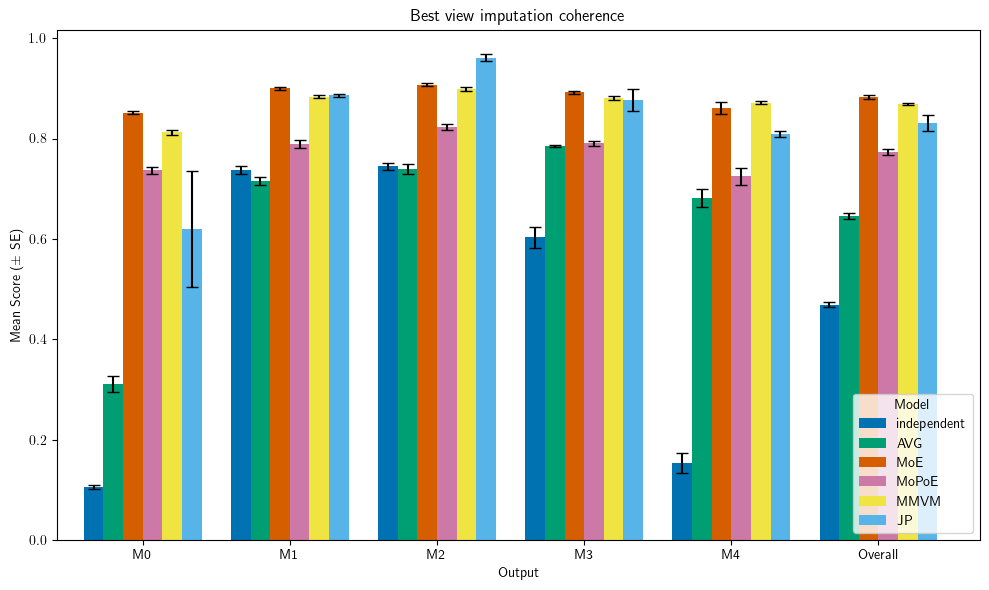

In [224]:
coherence_plots(df_subset, cols_best, "Output", "Best view imputation coherence", "results_figures/best_imputation_coherence_barplot.png")

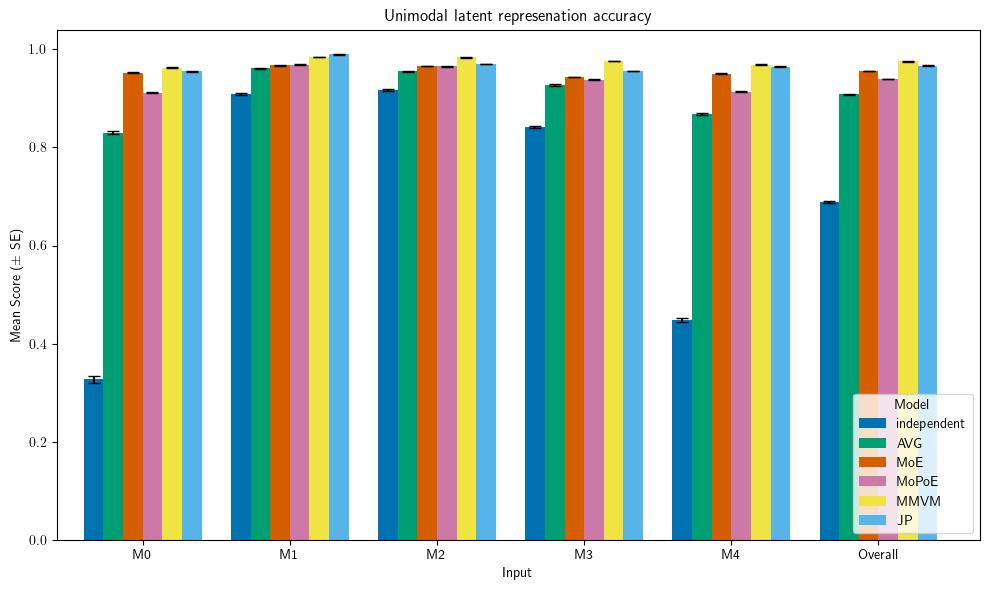

In [225]:
coherence_plots(df_subset, uni_cols, "Input", "Unimodal latent represenation accuracy", "results_figures/unimodal_barplot.png")

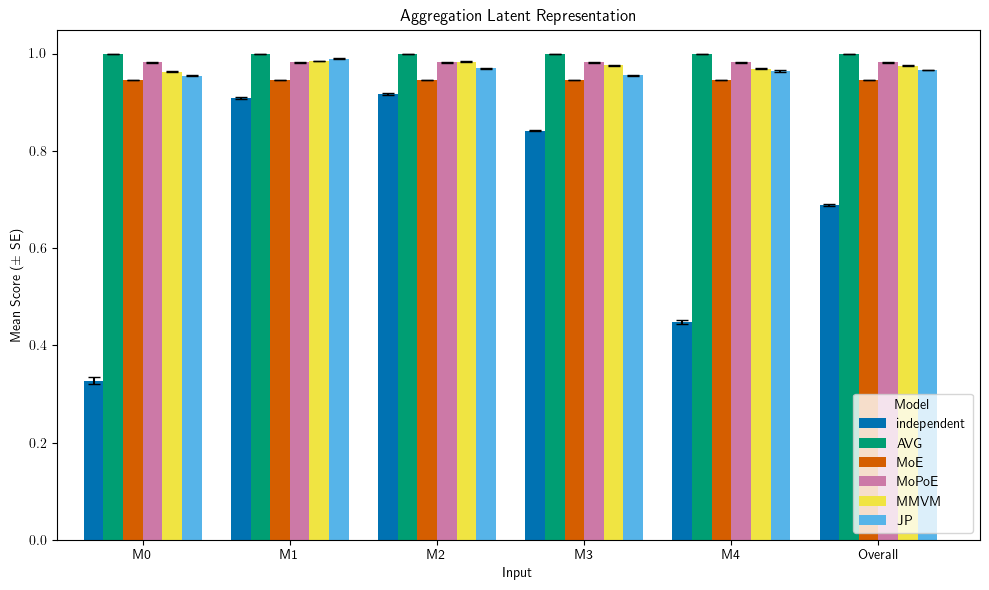

In [226]:
coherence_plots(df_subset, agg_cols, "Input", "Aggregation Latent Representation", "results_figures/agg_barplot.png")

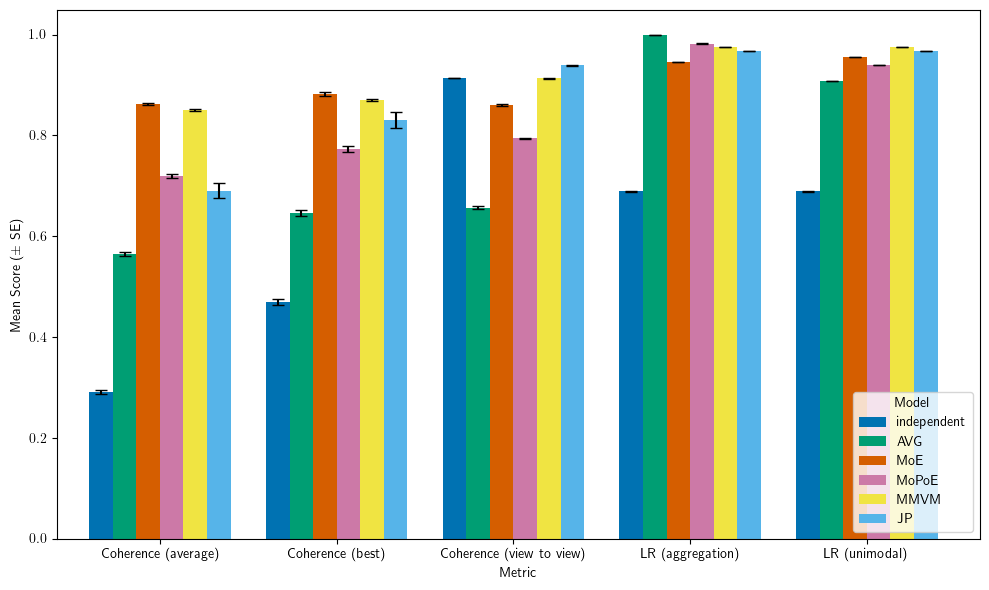

In [227]:
coherence_plots(df_subset, main_cols, "Metric", "", "results_figures/combined_results.png", combination_plot=True)

In [228]:
def two_axis_plot(df, filepath):
  _, axes = plt.subplots(2, 2, figsize=(10,8))
  axes = np.array(axes).reshape(-1)  
  y_axes = ['average_overall', 'best_overall', "agg_average", "unimodal_average"]
  y_titles =["Coherence (average)", "Coherence (best)",
             "Coherence (aggregation)", "LR (unimodal)"]
  for ax, y_axis, y_title in zip(axes, y_axes, y_titles):
    for model, group in df.groupby('model.name', observed=False):
        ax.scatter(
            group["final_scores/rec_loss"],
            group[y_axis],
            label=model,
            alpha=0.8
        )
    ax.set_xlabel("Reconstruction loss", fontsize=10)
    ax.set_ylabel(y_title, fontsize=10)
    if y_title == "LR (unimodal)":
      handles, labels = ax.get_legend_handles_labels()
      by_label = dict(zip(labels, handles))
      ax.legend(by_label.values(), by_label.keys(), title="Model", 
                loc =(0.6, 0.1), scatterpoints=1)
  
  plt.savefig(filepath)
  plt.show()

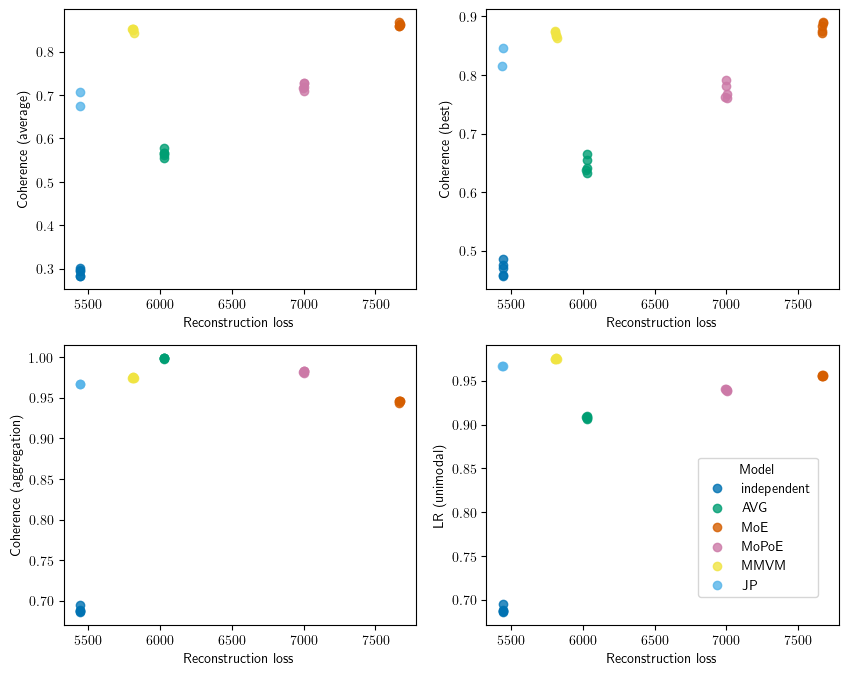

In [229]:
two_axis_plot(df_subset, "results_figures/recon_loss_plots.png")